<a href="https://colab.research.google.com/github/phenomenaldatalab/Foundations-of-AI-for-Business/blob/main/Exercise4_Evolutionary_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In-class Exercise (Total: 75 mins)
3 activities (with 1 minor discussion and 1 minor presentation)


*   Exercise 1.1 (30 mins)
*   Exercise 2 (15 mins)
*   Exercise 3 (30 mins)


# After-class Exercise (Total: 25 mins)
1 activity (with 1 minor discussion)


*   Exercise 1.2



# Exercise 1: Genetic Algorithms and VSR (55 mins)

## Exercise 1.1: Biological Example - Evolution Simulation (30 mins)


---


**Objective**:
To simulate biological evolution using genetic algorithms, emphasizing the role of variation, selection, and retention (VSR).


---



**Task**: Simulating Evolution with a Genetic Algorithm
    
**Scenario**: Imagine a population of organisms represented by binary strings, where each bit represents a genetic trait (e.g., 1 = resistant to disease, 0 = susceptible).

**Instructions**:

### Step 1: Generate a Random Population (2 mins)

Each organism is represented by a binary string of 10 traits (bits), and the population consists of 20 individuals. These binary strings are generated randomly.

In [ ]:
import random

# Parameters for the genetic algorithm
population_size = 20  # Number of individuals in the population
chromosome_length = 10  # Number of traits (genes) each individual has
mutation_rate = 0.03  # Probability of mutation in each individual

# Create a random population where each individual is a binary string
def create_population(size, length):
    return [[random.choice([0, 1]) for _ in range(length)] for _ in range(size)]

# Generate the initial population
population = create_population(population_size, chromosome_length)
print("Initial Population:", population)

Initial Population: [[1, 1, 1, 1, 1, 1, 0, 1, 0, 0], [1, 0, 1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 1, 1, 0, 0, 1, 1, 0, 1], [0, 1, 1, 0, 0, 1, 0, 0, 1, 1], [0, 0, 1, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 1, 0, 1, 0, 1, 0, 0, 0], [0, 1, 1, 1, 1, 1, 1, 0, 1, 1], [0, 1, 0, 1, 1, 1, 1, 0, 1, 1], [0, 0, 0, 0, 1, 0, 1, 0, 0, 1], [1, 0, 0, 0, 0, 1, 0, 1, 1, 1], [0, 1, 0, 0, 1, 0, 0, 1, 1, 0], [1, 0, 1, 1, 1, 1, 1, 1, 0, 1], [0, 1, 1, 1, 1, 1, 0, 0, 1, 1], [1, 0, 0, 1, 0, 1, 1, 1, 1, 0], [1, 1, 1, 0, 1, 1, 1, 0, 1, 0], [1, 1, 0, 0, 1, 1, 0, 1, 0, 0], [0, 1, 0, 0, 1, 1, 0, 0, 1, 1], [0, 1, 0, 1, 0, 1, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]


### Step 2: Create a Fitness Function (2 mins)

The fitness function evaluates each organism based on its ability to survive in a given environment. For simplicity, organisms with more 1s (favorable traits) have higher fitness.

In [ ]:
# Fitness function: individuals with more '1's are considered fitter
def fitness(individual):
    return sum(individual)  # The fitness score is simply the count of 1's

### Step 3: Apply Selection (2 mins)

Select two individuals for reproduction using tournament selection. The fittest individual from a random pair is chosen to reproduce.

In [ ]:
# Select two individuals for reproduction using tournament selection
def select(population):
    return max(random.sample(population, 2), key=fitness)

### Step 4: Apply Crossover and Mutation (3 mins)

Perform single-point crossover between two parents. A random point is chosen, and genes from both parents are combined to create offspring. Introduce mutation by flipping bits in the offspring with a small probability to maintain genetic diversity.   
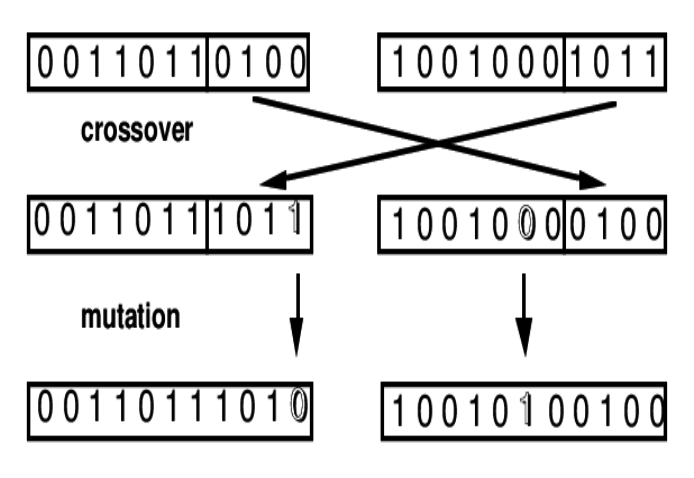

Later in step 5, students can adjust the crossover and mutation rates to observe the effect on the algorithm’s performance.   
   
**Note**
*   Mutation focus on refining current solutions (small steps), similar to hill-climbing or exploitation
*   Crossover promote diversity and bigger changes, akin to long-jumping or exploration

In [ ]:
# Single-point crossover based on crossover rate
def crossover(parent1, parent2, crossover_rate):
    if crossover_rate > 0 and random.random() < crossover_rate:  # Only apply crossover if the rate allows it
        point = random.randint(1, len(parent1) - 1)
        return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]
    else:
        return parent1, parent2  # No crossover if rate is 0

# Mutation based on mutation rate
def mutate(individual, mutation_rate):
    if mutation_rate > 0:  # Only mutate if the rate is greater than 0
        return [bit if random.random() > mutation_rate else 1 - bit for bit in individual]
    else:
        return individual  # No mutation if rate is 0

### Step 5: Evolve the Population (3 mins)

Repeat the process for 10 generations, applying selection, crossover, and mutation to the population.

### Trials (8 mins):
1. Analyze how the population changes over time. (2 mins)
2. What happens to the population's fitness as selection occurs? (2 mins)
3. What happens when the mutation rate is too high or too low? (2 mins)
4. What happens when the crossover rate is too high or too low? (2 mins)

Enter mutation rate (0.0 to 1.0): 1
Enter crossover rate (0.0 to 1.0): 0
Generation 1: Avg Fitness = 5.05
Generation 2: Avg Fitness = 4.35
Generation 3: Avg Fitness = 5.35
Generation 4: Avg Fitness = 4.55
Generation 5: Avg Fitness = 5.10
Generation 6: Avg Fitness = 4.70
Generation 7: Avg Fitness = 5.05
Generation 8: Avg Fitness = 4.85
Generation 9: Avg Fitness = 5.05
Generation 10: Avg Fitness = 4.85


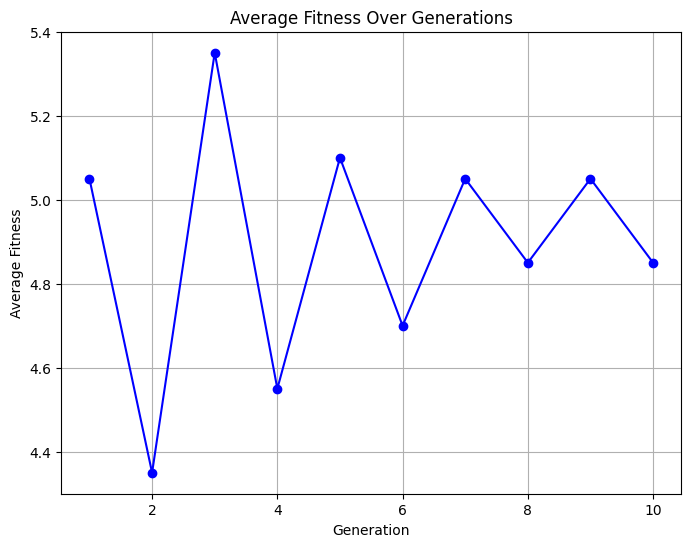

Best Individual: [0, 0, 0, 1, 0, 1, 1, 0, 1, 1], Fitness: 5


In [ ]:
import matplotlib.pyplot as plt

# Evolve the population with given mutation and crossover rates
def evolve(population, mutation_rate, crossover_rate):
    # If both rates are 0, return the same population (no evolution)
    if mutation_rate == 0 and crossover_rate == 0:
        return population

    new_population = []
    for _ in range(len(population) // 2):  # Loop through half the population size (parent pairs)
        parent1, parent2 = select(population), select(population)
        child1, child2 = crossover(parent1, parent2, crossover_rate)
        new_population.append(mutate(child1, mutation_rate))
        new_population.append(mutate(child2, mutation_rate))
    return new_population

# Initialize population with random binary strings
def create_population(pop_size, chromosome_length):
    return [[random.choice([0, 1]) for _ in range(chromosome_length)] for _ in range(pop_size)]

# Parameters
population_size = 20
chromosome_length = 10
generations = 10

# Allow students to input the mutation and crossover rates
mutation_rate = float(input("Enter mutation rate (0.0 to 1.0): "))  # Example: 0.1
crossover_rate = float(input("Enter crossover rate (0.0 to 1.0): "))  # Example: 0.1

# Initialize the population
population = create_population(population_size, chromosome_length)

# Track fitness over generations
avg_fitness_over_generations = []

# Run the genetic algorithm for multiple generations
for generation in range(generations):
    population = evolve(population, mutation_rate, crossover_rate)
    avg_fitness = sum(fitness(ind) for ind in population) / len(population)
    avg_fitness_over_generations.append(avg_fitness)  # Store the average fitness for visualization
    print(f"Generation {generation+1}: Avg Fitness = {avg_fitness:.2f}")

# Plot the average fitness over generations
plt.figure(figsize=(8, 6))
plt.plot(range(1, generations + 1), avg_fitness_over_generations, marker='o', linestyle='-', color='b')
plt.title('Average Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.grid(True)
plt.show()

# Print the best individual in the final population
best_individual = max(population, key=fitness)
print(f"Best Individual: {best_individual}, Fitness: {fitness(best_individual)}")

## Discussion Questions (10 mins):
1. How does this process simulate natural selection? (3 mins)
2. What role does mutation play in helping the population adapt? (3 mins)
3. How does crossover combine beneficial traits, and how does this improve fitness? (4 mins)

## Exercise 1.2: Business Example - Innovation and Product Development (25 mins)


---


**Objective:**
To demonstrate how genetic algorithms can be applied to optimize product features and promote innovation in a business setting.


---



**Task**: Simulating Product Innovation with Genetic Algorithms  

**Scenario**:
A company is developing a new smartphone. Each smartphone is represented by a binary string where each bit represents a product feature (e.g., 1 = long battery life, 0 = short battery life)   

**Instructions**:

### Step 1: Generate a Population of Smartphone Designs (1 min)

Each product design is represented as a binary string of 8 features, and there are 10 designs in the population.

In [ ]:
population_size = 10  # Number of product designs in the population
chromosome_length = 8  # Each bit represents a product feature (e.g., battery life, price)

# Create a random population of product designs represented as binary strings
def create_population(size, length):
    return [[random.choice([0, 1]) for _ in range(length)] for _ in range(size)]

# Generate the initial population of product designs
population = create_population(population_size, chromosome_length)
print("Initial Product Designs:", population)

Initial Product Designs: [[0, 0, 0, 1, 0, 0, 0, 1], [1, 0, 1, 1, 1, 0, 1, 1], [0, 1, 0, 0, 1, 1, 0, 0], [0, 0, 0, 1, 0, 1, 1, 1], [1, 0, 1, 1, 1, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 1, 0, 0, 1, 0], [1, 1, 0, 1, 1, 0, 0, 1], [1, 0, 1, 0, 1, 0, 0, 1], [0, 1, 1, 0, 1, 1, 1, 1]]


### Step 2: Define a Fitness Function Based on Customer Preferences (1 min)

The fitness function evaluates product designs based on customer satisfaction, where more 1s represent better features.

In [ ]:
# Fitness function: products with more '1's are considered better
def fitness(individual):
    return sum(individual)  # The fitness score is based on product features (more 1's = better)

### Step 3: Selection of Product Designs (1 min)

Select two product designs for reproduction using tournament selection based on fitness scores.

In [ ]:
# Select two product designs for reproduction using tournament selection
def select(population):
    return max(random.sample(population, 2), key=fitness)

### Step 4: Perform Crossover Between Parent Designs and Apply Mutation to Product Features (1 min)

Crossover combines features from two parent designs to create two new offspring. Introduce mutations to flip random product features.

In [ ]:
# Single-point crossover based on crossover rate for product designs
def crossover(parent1, parent2, crossover_rate):
    if crossover_rate > 0 and random.random() < crossover_rate:  # Apply crossover based on rate
        point = random.randint(1, len(parent1) - 1)
        return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]
    else:
        return parent1, parent2  # No crossover if rate is 0

# Mutation based on mutation rate for product designs
def mutate(individual, mutation_rate):
    if mutation_rate > 0:  # Only apply mutation if rate > 0
        return [bit if random.random() > mutation_rate else 1 - bit for bit in individual]
    else:
        return individual  # No mutation if rate is 0

### Step 5: Evolve the Population of Products (2 mins)

Repeat the process of selection, crossover, and mutation for several generations to improve product designs.

### Reflection (11 mins):
1. Observe how the designs evolve over multiple generations. (2 min)
2. How does a crossover rate (exploration) affect the diversity of product designs, similar to long-jumping? (3 mins)
3. How does a mutation rate (exploitation) fine-tune designs, similar to hill-climbing? (3 mins)
4. What trade-offs emerge in the process? (3 mins)

Enter mutation rate (0.0 to 1.0): 0.0
Enter crossover rate (0.0 to 1.0): 0.1
Generation 1: Average Fitness = 6.60
Generation 2: Average Fitness = 7.10
Generation 3: Average Fitness = 7.10
Generation 4: Average Fitness = 7.40
Generation 5: Average Fitness = 7.70
Generation 6: Average Fitness = 7.90
Generation 7: Average Fitness = 8.00
Generation 8: Average Fitness = 8.00
Generation 9: Average Fitness = 8.00
Generation 10: Average Fitness = 8.00


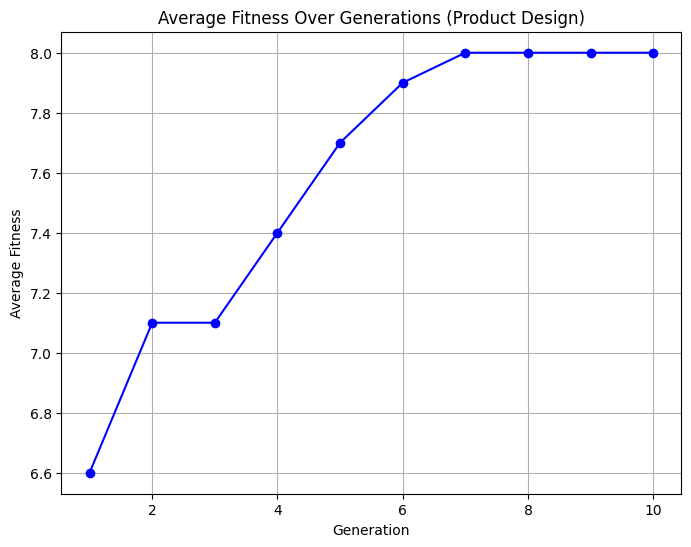

Best Product Design: [0, 0, 1, 1, 1, 1, 1, 1, 1, 1], Fitness: 8


In [ ]:
import matplotlib.pyplot as plt

# Evolve the population of product designs over multiple generations with mutation and crossover
def evolve(population, mutation_rate, crossover_rate):
    # If both rates are 0, no evolution, just return the same population
    if mutation_rate == 0 and crossover_rate == 0:
        return population

    new_population = []
    for _ in range(len(population) // 2):  # Loop through half the population (pairs of designs)
        parent1, parent2 = select(population), select(population)
        child1, child2 = crossover(parent1, parent2, crossover_rate)
        new_population.append(mutate(child1, mutation_rate))
        new_population.append(mutate(child2, mutation_rate))
    return new_population

# Initialize product designs with random binary strings (representing product features)
def create_population(pop_size, chromosome_length):
    return [[random.choice([0, 1]) for _ in range(chromosome_length)] for _ in range(pop_size)]

# Parameters
population_size = 20  # Number of product designs in the population
chromosome_length = 10  # Number of features for each product design
generations = 10  # Number of generations to simulate

# Allow students to input the mutation and crossover rates
mutation_rate = float(input("Enter mutation rate (0.0 to 1.0): "))  # Example: 0.1
crossover_rate = float(input("Enter crossover rate (0.0 to 1.0): "))  # Example: 0.1

# Initialize the population of product designs
population = create_population(population_size, chromosome_length)

# Track fitness over generations
avg_fitness_over_generations = []

# Evolve the population of product designs over multiple generations
for generation in range(generations):
    population = evolve(population, mutation_rate, crossover_rate)
    avg_fitness = sum(fitness(ind) for ind in population) / len(population)
    avg_fitness_over_generations.append(avg_fitness)  # Store average fitness for visualization
    print(f"Generation {generation+1}: Average Fitness = {avg_fitness:.2f}")

# Plot the average fitness over generations
plt.figure(figsize=(8, 6))
plt.plot(range(1, generations + 1), avg_fitness_over_generations, marker='o', linestyle='-', color='b')
plt.title('Average Fitness Over Generations (Product Design)')
plt.xlabel('Generation')
plt.ylabel('Average Fitness')
plt.grid(True)
plt.show()

# Print the best product design in the final population
best_individual = max(population, key=fitness)
print(f"Best Product Design: {best_individual}, Fitness: {fitness(best_individual)}")

## Discussion Questions (8 mins):
1. How does the process of using genetic algorithms for product innovation mimic real-world business competition? (4 mins)
2. How does selection based on customer preferences drive the evolution of the product? (4 mins)

# Excercise 2: Different Landscapes (15 mins)

Task: Draw Learning Paths (12 mins)

Split into groups. On the screen, capture each landscape as generated by the code below. Then, by hand(post it on ppt or somewhere to draw the lines), sketch several possible learning paths an agent might take across the landscape. Use different colored pens or varied line styles to differentiate the paths.



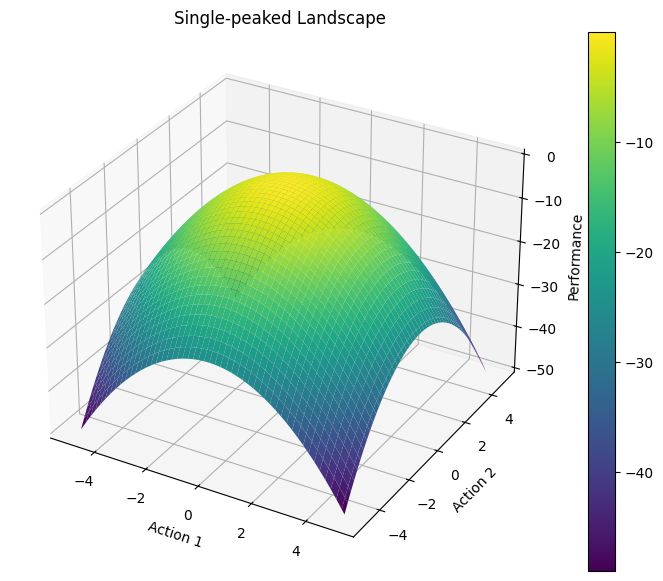

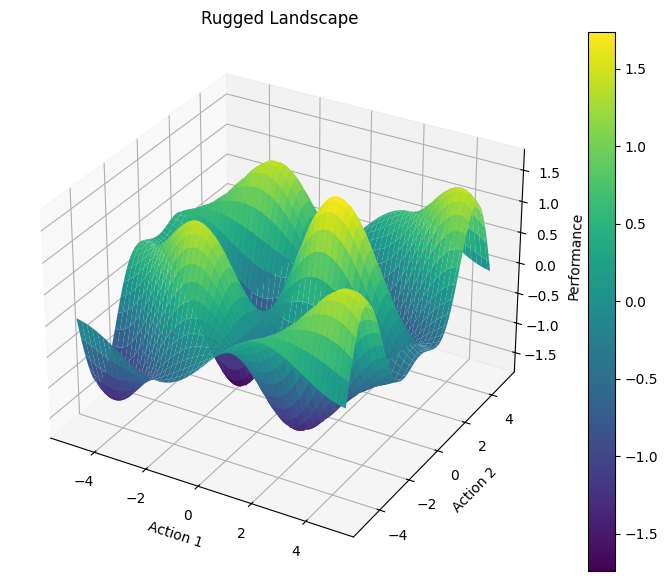

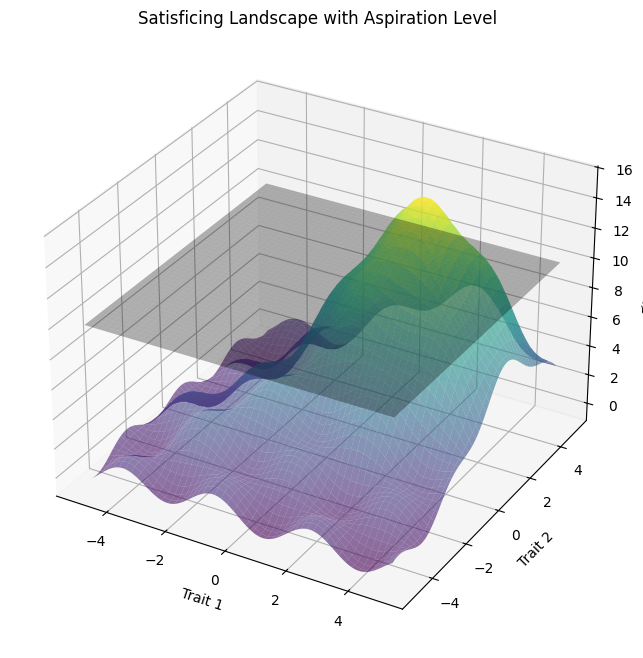

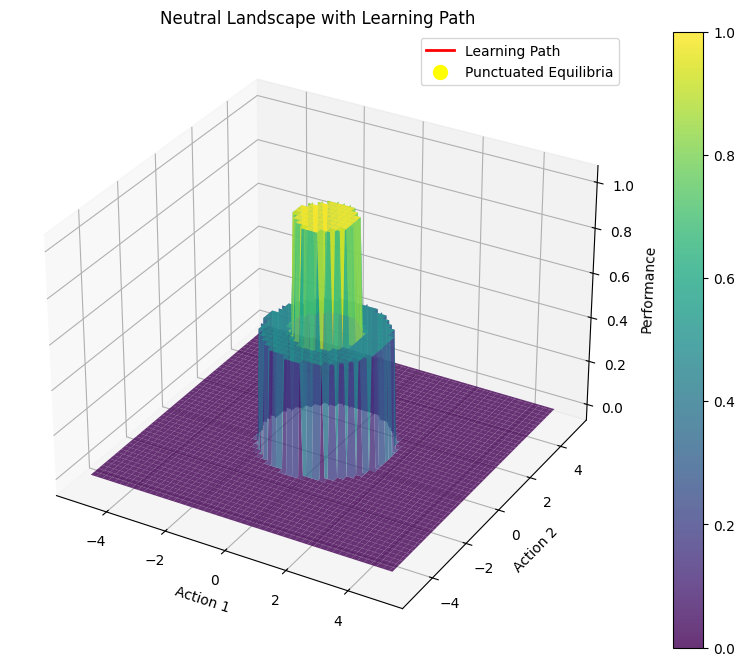

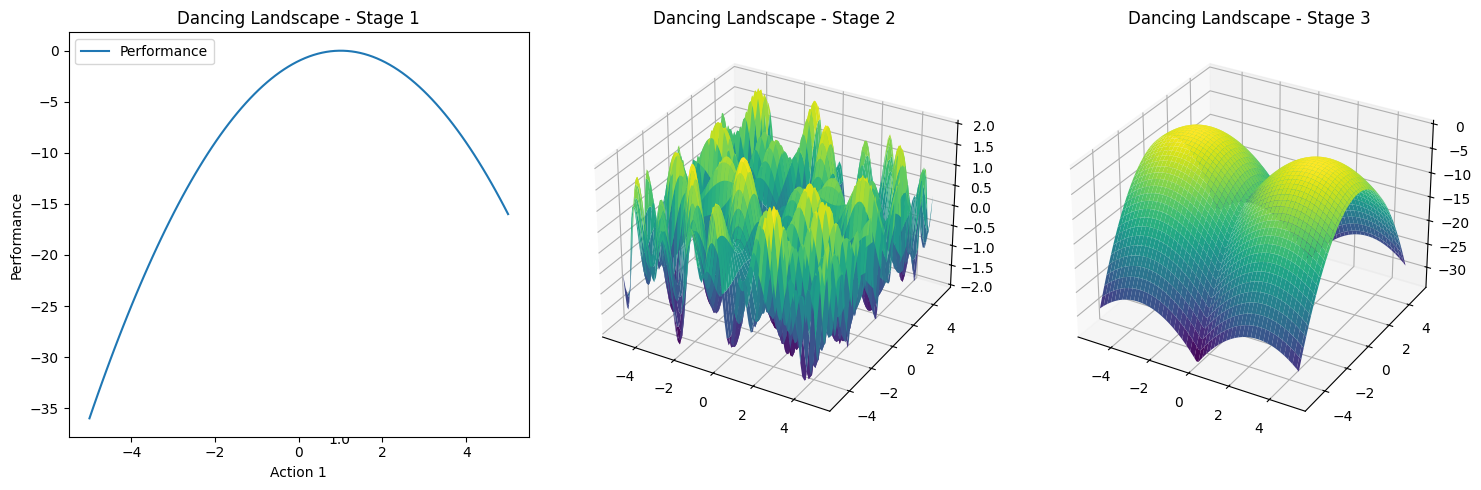

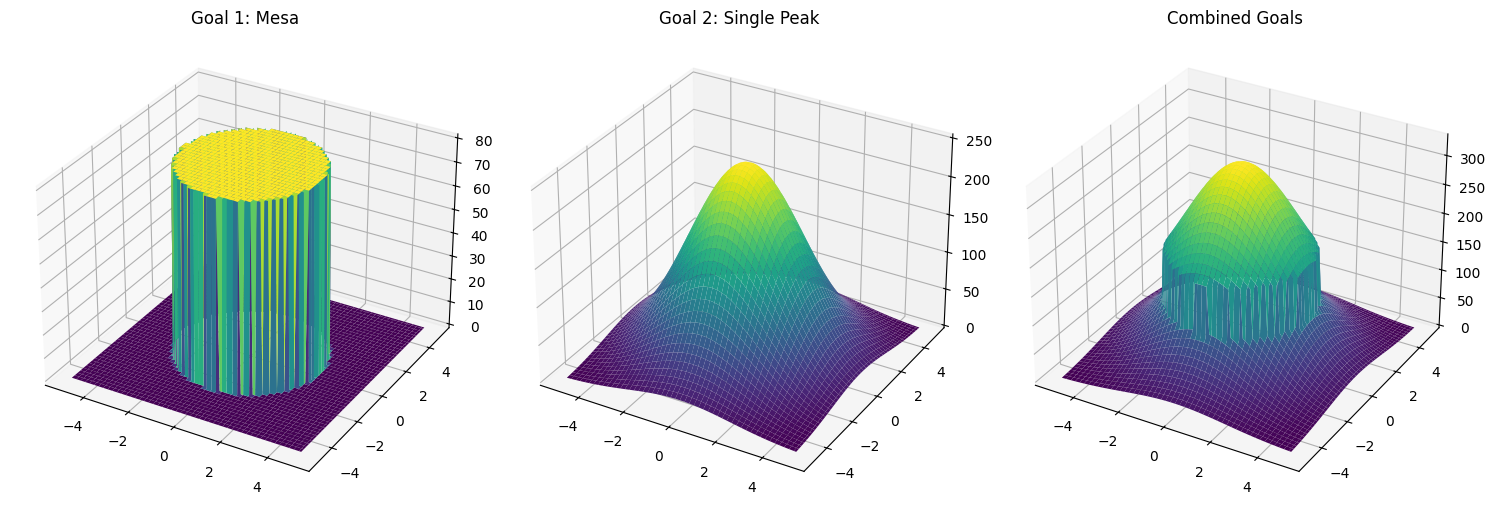

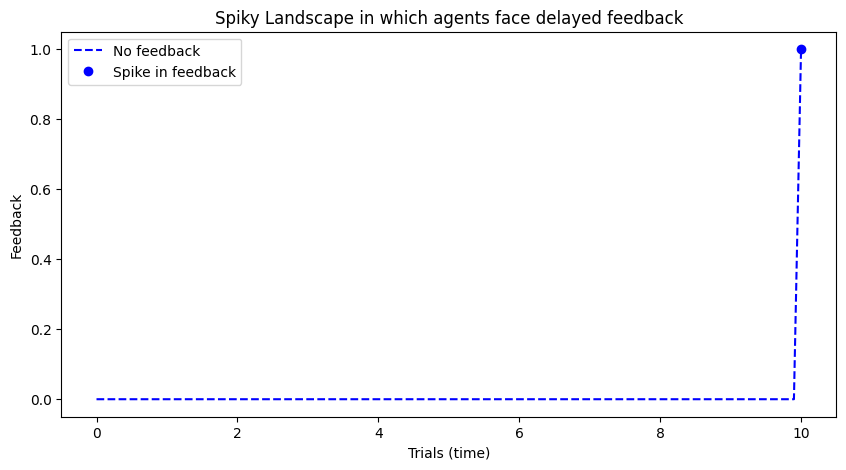

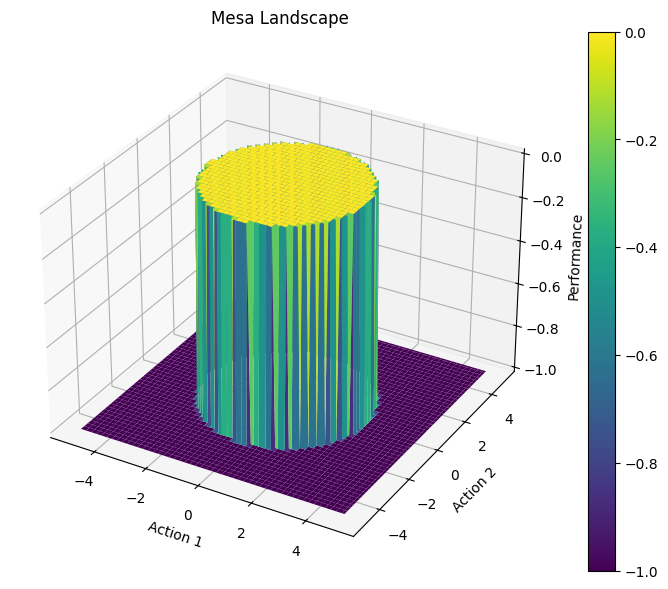

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata  # Add this import

def plot_landscape(X, Y, Z, title):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Action 1')
    ax.set_ylabel('Action 2')
    ax.set_zlabel('Performance')
    ax.set_title(title)
    plt.colorbar(surf)
    plt.show()

# 1. Single-peaked landscape
def single_peaked():
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    Z = -(X**2 + Y**2)
    plot_landscape(X, Y, Z, "Single-peaked Landscape")

# 2. Rugged landscape
def rugged():
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    Z = np.sin(X) * np.cos(Y) + np.sin(0.5*X) * np.cos(1.5*Y)
    plot_landscape(X, Y, Z, "Rugged Landscape")

# 3. Satisficing landscape
def satisficing():
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))

    # Rugged landscape with one dominant global maximum and multiple local maxima
    Z = (
        np.sin(2 * X) * np.cos(2 * Y)  # Adds more prominent local maxima
    )
    Z += 15 * np.exp(-0.1 * ((X - 2) ** 2 + (Y - 2) ** 2))  # Create a global maximum significantly higher than local maxima
    Z += 3 * np.exp(-0.2 * ((X + 2) ** 2 + (Y + 2) ** 2))  # Create a noticeable local maximum

    # Create an aspiration level plane below the global maximum and above local maxima
    aspiration_level = 10  # Set the aspiration level
    Z_plane = np.full_like(Z, aspiration_level)  # Create a plane at the aspiration level

    # Adjust the Z values to ensure the global maximum remains above the plane
    Z = np.where(Z > aspiration_level, Z, Z)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
    ax.plot_surface(X, Y, Z_plane, cmap='gray', alpha=0.3)
    ax.set_xlabel('Trait 1')
    ax.set_ylabel('Trait 2')
    ax.set_zlabel('Fitness')
    ax.set_title('Satisficing Landscape with Aspiration Level')
    plt.show()


# 4. Neutral landscape with learning path
def neutral():
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    Z[X**2 + Y**2 < 4] = 0.5
    Z[X**2 + Y**2 < 1] = 1

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

    # Generate a learning path
    np.random.seed(42)  # for reproducibility
    path_length = 100
    x_path = np.zeros(path_length)
    y_path = np.zeros(path_length)
    z_path = np.zeros(path_length)

    # Initial position
    x_path[0] = np.random.uniform(-5, 5)
    y_path[0] = np.random.uniform(-5, 5)
    z_path[0] = griddata((X.ravel(), Y.ravel()), Z.ravel(), (x_path[0], y_path[0]), method='nearest')

    for i in range(1, path_length):
        # Random walk with small steps
        step_size = 0.2
        x_path[i] = x_path[i-1] + np.random.normal(0, step_size)
        y_path[i] = y_path[i-1] + np.random.normal(0, step_size)

        # Ensure the path stays within bounds
        x_path[i] = np.clip(x_path[i], -5, 5)
        y_path[i] = np.clip(y_path[i], -5, 5)

        # Get the z-value for the current position using interpolation
        z_path[i] = griddata((X.ravel(), Y.ravel()), Z.ravel(), (x_path[i], y_path[i]), method='nearest')

    # Plot the learning path
    ax.plot(x_path, y_path, z_path, color='red', linewidth=2, label='Learning Path')

    # Highlight punctuated equilibria
    equilibria_points = [0, 30, 60, 90]  # Example points where equilibria occur
    ax.scatter(x_path[equilibria_points], y_path[equilibria_points], z_path[equilibria_points],
               color='yellow', s=100, label='Punctuated Equilibria')

    ax.set_xlabel('Action 1')
    ax.set_ylabel('Action 2')
    ax.set_zlabel('Performance')
    ax.set_title("Neutral Landscape with Learning Path")
    plt.colorbar(surf)
    ax.legend()
    plt.show()

# 5. Dancing landscape
def dancing():
    fig = plt.figure(figsize=(15, 5))
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))

    for i in range(3):
        ax = fig.add_subplot(131 + i, projection='3d')
        if i == 0:
            # Single peak (Stage 1 as 2D graph with only x and y axis)
            X_2d = np.linspace(-5, 5, 100)
            Y_2d = -((X_2d - 1) ** 2)  # 2D graph, y axis is performance
            ax = fig.add_subplot(131 + i)
            ax.plot(X_2d, Y_2d, label='Performance')
            ax.set_xlabel('Action 1')
            ax.set_ylabel('Performance')
            ax.set_title('Dancing Landscape - Stage 1')
            ax.legend()
        elif i == 1:
            # Rugged landscape (Stage 2)
            Z = np.sin(2 * X) * np.cos(2 * Y) + np.sin(X * Y)
            ax.plot_surface(X, Y, Z, cmap='viridis')
            ax.set_title('Dancing Landscape - Stage 2')
        else:
            # Shifted valleys (Stage 3)
            Z = -np.minimum((X + 3) ** 2 + Y ** 2, (X - 3) ** 2 + Y ** 2)
            ax.plot_surface(X, Y, Z, cmap='viridis')
            ax.set_title('Dancing Landscape - Stage 3')

    plt.tight_layout()
    plt.show()
# 5. Skipky landscape
def spiky():
    trials = np.linspace(0, 10, 100)
    feedback = np.zeros_like(trials)
    feedback[-1] = 1  # Spike in feedback at the end

    plt.figure(figsize=(10, 5))
    plt.plot(trials, feedback, 'b--', label='No feedback')
    plt.plot([trials[-1]], [feedback[-1]], 'bo', label='Spike in feedback')
    plt.xlabel('Trials (time)')
    plt.ylabel('Feedback')
    plt.title('Spiky Landscape in which agents face delayed feedback')
    plt.legend()
    plt.show()

# 7. Multiple goals landscape
def multiple_goals():
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))

    # Goal 1: Mesa (60 < Z1 < 100)
    Z1 = np.zeros_like(X)
    Z1[(X**2 + Y**2) < 9] = 80  # Mesa region with height 80 (within the range 60 to 100)
    Z1[(X**2 + Y**2) >= 9] = 0   # Outside the mesa region

    # Goal 2: Single-peak (20 < Z2 < 30)
    Z2 = 250 * np.exp(-0.1 * (X**2 + Y**2))  # Single peak

    # Combined Goal: Z1 + Z2
    Z_combined = Z1 + Z2

    fig = plt.figure(figsize=(15, 5))

    ax1 = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Z1, cmap='viridis')
    ax1.set_title("Goal 1: Mesa")

    ax2 = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z2, cmap='viridis')
    ax2.set_title("Goal 2: Single Peak")

    ax3 = fig.add_subplot(133, projection='3d')
    surf3 = ax3.plot_surface(X, Y, Z_combined, cmap='viridis')
    ax3.set_title("Combined Goals")

    plt.tight_layout()
    plt.show()

# 8. Mesa landscape
def mesa():
    X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
    Z = np.zeros_like(X)
    Z[X**2 + Y**2 > 9] = -1
    plot_landscape(X, Y, Z, "Mesa Landscape")

# Run all visualizations
single_peaked()
rugged()
satisficing()
neutral()
dancing()
multiple_goals()
spiky()
mesa()

## Multiple Goal Landscape (3 mins)

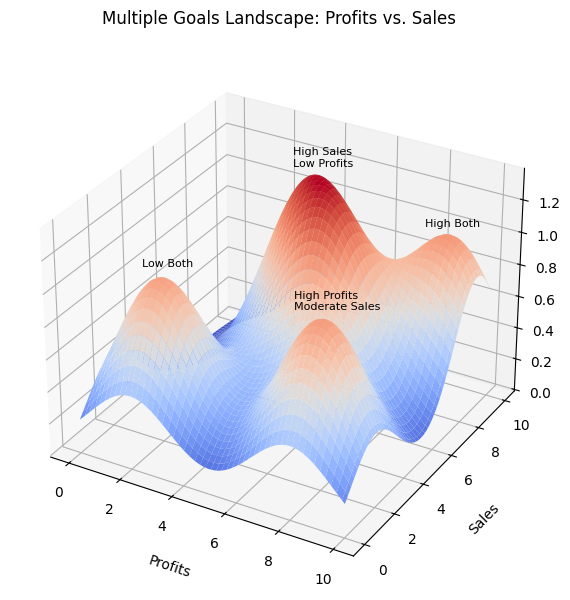

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the data for the performance landscape
# X-axis for Profits, Y-axis for Sales
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)

# Define more peaks for different goals
Z1 = np.exp(-((X - 8)**2 + (Y - 2)**2) / 5)  # High profits, moderate sales
Z2 = np.exp(-((X - 4)**2 + (Y - 8)**2) / 5)  # High sales, low profits
Z3 = np.exp(-((X - 6)**2 + (Y - 6)**2) / 5)  # Moderate profits and sales
Z4 = np.exp(-((X - 2)**2 + (Y - 2)**2) / 5)  # Low profits, low sales
Z5 = np.exp(-((X - 9)**2 + (Y - 9)**2) / 5)  # High profits and high sales

# Combined landscape
Z = Z1 + Z2 + Z3 + Z4 + Z5

# Plotting the landscape
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface plot with a clean white background
ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')

# Add labels for peaks
ax.text(7, 2, 1.05, 'High Profits\nModerate Sales', color='black', fontsize=8)
ax.text(3.5, 8, 1.3, 'High Sales\nLow Profits', color='black', fontsize=8)
ax.text(1.3, 2, 1.05, 'Low Both', color='black', fontsize=8)
ax.text(8, 9, 1.05, 'High Both', color='black', fontsize=8)

# Add axis labels
ax.set_xlabel('Profits', labelpad=10)
ax.set_ylabel('Sales', labelpad=10)
ax.set_zlabel('Performance', labelpad=10)

# Set title
ax.set_title('Multiple Goals Landscape: Profits vs. Sales', pad=20)

# Show the plot
plt.show()

# Exercise 3: How do different performance landscapes influence decision-making and strategy in practice? (30 min)

#### Materials Needed:
- Laptop design templates (see below)

### Step 1: Form Groups (5 min)
Form groups of 4 students, each assigned a different landscape type:
- Single-peaked
- Rugged
- Satisficing
- Neutral
- Dancing
- Multiple Goals
- Spiky
- Mesa

### Step 2: Design Process Simulation (15 min)
Groups simulate going through their design process using the provided laptop design template (see below).

Consider the following aspects:
- How to explore design options
- How to evaluate performance
- How to make decisions given their landscape's characteristics

Make notes on:
- Key decision points
- How you are applying landscape-specific strategies
- Challenges you encounter

### Step 3: Group Presentations (10 min)
Each group should briefly address the following questions in a 1-2 minute presentation:
- *(If you are not from the single-peaked group)* Why is gradient descent not enough for navigating your landscape type?
- How did your landscape type influence your laptop design decisions? Provide one specific example.
- What was your biggest challenge, and how did you overcome it?
- Beyond laptops, how might a real company's strategy align with your landscape type?

---




## Laptop Design Templates

#### Basic Laptop Characteristics:
- **Processor:** Low-end | Mid-range | High-end
- **RAM:** 4GB | 8GB | 16GB | 32GB
- **Storage:** 256GB SSD | 512GB SSD | 1TB SSD
- **Screen Size:** 13" | 15" | 17"
- **Battery Life:** 6 hours | 10 hours | 14 hours
- **Weight:** Ultralight | Standard | Heavy-duty
- **Price Range:** Budget | Mid-range | Premium

#### Performance Metrics:
- **Processing Speed:** Scale 1-10
- **Multitasking Capability:** Scale 1-10
- **Graphics Performance:** Scale 1-10
- **Portability:** Scale 1-10
- **Build Quality:** Scale 1-10
- **User Satisfaction:** Scale 1-10